In [1]:
import pandas as pd

In [2]:
# Load the dataset
df = pd.read_csv(r'C:\Users\met00546\formation\Projet data analysis\Procurement KPI Analysis Dataset.csv')

In [3]:
print(df.head())

      PO_ID         Supplier  Order_Date Delivery_Date    Item_Category  \
0  PO-00001        Alpha_Inc  2023-10-17    2023-10-25  Office Supplies   
1  PO-00002  Delta_Logistics  2022-04-25    2022-05-05  Office Supplies   
2  PO-00003         Gamma_Co  2022-01-26    2022-02-15              MRO   
3  PO-00004    Beta_Supplies  2022-10-09    2022-10-28        Packaging   
4  PO-00005  Delta_Logistics  2022-09-08    2022-09-20    Raw Materials   

  Order_Status  Quantity  Unit_Price  Negotiated_Price  Defective_Units  \
0    Cancelled      1176       20.13             17.81              NaN   
1    Delivered      1509       39.32             37.34            235.0   
2    Delivered       910       95.51             92.26             41.0   
3    Delivered      1344       99.85             95.52            112.0   
4    Delivered      1180       64.07             60.53            171.0   

  Compliance  
0        Yes  
1        Yes  
2        Yes  
3        Yes  
4         No  


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 777 entries, 0 to 776
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   PO_ID             777 non-null    object 
 1   Supplier          777 non-null    object 
 2   Order_Date        777 non-null    object 
 3   Delivery_Date     690 non-null    object 
 4   Item_Category     777 non-null    object 
 5   Order_Status      777 non-null    object 
 6   Quantity          777 non-null    int64  
 7   Unit_Price        777 non-null    float64
 8   Negotiated_Price  777 non-null    float64
 9   Defective_Units   641 non-null    float64
 10  Compliance        777 non-null    object 
dtypes: float64(3), int64(1), object(7)
memory usage: 66.9+ KB


In [5]:
# corriger le type de donnée
df['Order_Date'] = pd.to_datetime(df['Order_Date'], errors='coerce')
df['Delivery_Date'] = pd.to_datetime(df['Delivery_Date'], errors='coerce')


In [6]:
# corriger le type de donnée pour Defective_Units
df['Defective_Units'] = df['Defective_Units'].fillna(0).astype(int)
df['Defective_Units'] = df['Defective_Units'].astype('Int64')


In [7]:
df.describe()

,Order_Date,Delivery_Date,Quantity,Unit_Price,Negotiated_Price,Defective_Units
count,777,690,777.000000,777.000000,777.000000,777.0
mean,2022-12-28 23:15:31.274131456,2023-01-12 03:16:10.434782720,1094.660232,58.283822,53.660721,61.710425
min,2022-01-01 00:00:00,2022-01-06 00:00:00,51.000000,10.840000,9.270000,0.0
25%,2022-07-02 00:00:00,2022-07-19 18:00:00,615.000000,33.290000,30.460000,11.0
50%,2022-12-24 00:00:00,2023-01-19 12:00:00,1075.000000,58.950000,53.800000,38.0
75%,2023-07-07 00:00:00,2023-07-18 00:00:00,1548.000000,83.130000,76.550000,85.0
max,2024-01-01 00:00:00,2024-01-12 00:00:00,5000.000000,109.170000,107.390000,321.0
std,NaN,NaN,647.844551,28.101315,26.094930,68.971194


In [8]:
# Calculate Defect Rate and Defect Rate Percentage
df['Defect_Rate'] = (df['Defective_Units'] / df['Quantity']).round(2)
df['Defect_Rate_Pct'] = (df['Defect_Rate'] * 100).round(2)
print(df[['Defective_Units', 'Quantity', 'Defect_Rate', 'Defect_Rate_Pct']].head())

   Defective_Units  Quantity  Defect_Rate  Defect_Rate_Pct
0                0      1176          0.0              0.0
1              235      1509         0.16             16.0
2               41       910         0.05              5.0
3              112      1344         0.08              8.0
4              171      1180         0.14             14.0


In [9]:
print(df['Order_Status'].unique())

['Cancelled' 'Delivered' 'Partially Delivered' 'Pending']


In [10]:
print(df['Supplier'].unique())

['Alpha_Inc' 'Delta_Logistics' 'Gamma_Co' 'Beta_Supplies' 'Epsilon_Group']


In [11]:
print(df['Item_Category'].unique())

['Office Supplies' 'MRO' 'Packaging' 'Raw Materials' 'Electronics']


In [12]:
print(df['Compliance'].unique())

['Yes' 'No']


In [13]:
#delivery_date earlier than order_date
invalid_dates = df[
    (df['Delivery_Date'].notna()) &
    (df['Order_Date'].notna()) &
    (df['Delivery_Date'] < df['Order_Date'])
]

invalid_dates[['PO_ID', 'Order_Date', 'Delivery_Date', 'Order_Status']]


,PO_ID,Order_Date,Delivery_Date,Order_Status
100,PO-00101,2022-02-27,2022-02-22,Delivered


In [14]:
# Permuter les dates pour cette anomalie unique (j ai pensé que c'est une erreur de saisie, donc j'ai corrigé au lieu de supprimer la ligne, la supression est aussi une option)
mask = df['Delivery_Date'] < df['Order_Date']
df.loc[mask, ['Order_Date', 'Delivery_Date']] = df.loc[mask, ['Delivery_Date', 'Order_Date']].values


In [15]:
# Find orders with missing Delivery_Date and Order_Status as 'Pending'
df.loc[
    (df['Delivery_Date'].isna()) &
    (df['Order_Status'] == 'Pending'),
    ['PO_ID', 'Delivery_Date', 'Order_Status', 'Supplier']
]


,PO_ID,Delivery_Date,Order_Status,Supplier
49,PO-00050,NaT,Pending,Alpha_Inc
145,PO-00146,NaT,Pending,Gamma_Co
379,PO-00380,NaT,Pending,Alpha_Inc
446,PO-00447,NaT,Pending,Gamma_Co
704,PO-00705,NaT,Pending,Delta_Logistics
742,PO-00743,NaT,Pending,Alpha_Inc


In [16]:
df_pending = df[df['Order_Status'] == 'Pending']


In [17]:
# Analyze Delivery_Date completeness within Pending orders 
pending_total = len(df_pending)

pending_delivery_na = df_pending['Delivery_Date'].isna().sum()
pending_delivery_notna = df_pending['Delivery_Date'].notna().sum()

pending_pct = pd.DataFrame({
    'Condition': [
        'Pending & Delivery_Date IS NA',
        'Pending & Delivery_Date NOT NA'
    ],
    'Count': [
        pending_delivery_na,
        pending_delivery_notna
    ],
    'Percentage (%)': [
        round(pending_delivery_na / pending_total * 100, 2),
        round(pending_delivery_notna / pending_total * 100, 2)
    ]
})

pending_pct


,Condition,Count,Percentage (%)
0,Pending & Delivery_Date IS NA,6,7.41
1,Pending & Delivery_Date NOT NA,75,92.59


In [18]:
#
df['Lead_Time_Days'] = (
    df['Delivery_Date'] - df['Order_Date']
).dt.days
print(df[['Order_Date', 'Delivery_Date', 'Lead_Time_Days']].head(20))

   Order_Date Delivery_Date  Lead_Time_Days
0  2023-10-17    2023-10-25             8.0
1  2022-04-25    2022-05-05            10.0
2  2022-01-26    2022-02-15            20.0
3  2022-10-09    2022-10-28            19.0
4  2022-09-08    2022-09-20            12.0
5  2022-08-17    2022-08-29            12.0
6  2022-05-23    2022-06-03            11.0
7  2022-04-15    2022-04-29            14.0
8  2023-11-24    2023-11-28             4.0
9  2023-07-13    2023-07-25            12.0
10 2022-03-31    2022-04-15            15.0
11 2023-08-28    2023-09-11            14.0
12 2023-03-09    2023-03-26            17.0
13 2022-02-02           NaT             NaN
14 2022-01-31    2022-02-18            18.0
15 2022-04-06    2022-04-21            15.0
16 2022-08-12    2022-08-31            19.0
17 2022-08-27    2022-09-04             8.0
18 2023-06-02    2023-06-05             3.0
19 2023-09-09    2023-09-24            15.0


In [19]:
df.describe()

,Order_Date,Delivery_Date,Quantity,Unit_Price,Negotiated_Price,Defective_Units,Defect_Rate,Defect_Rate_Pct,Lead_Time_Days
count,777,690,777.000000,777.000000,777.000000,777.0,777.0,777.0,690.000000
mean,2022-12-28 23:06:15.289575424,2023-01-12 03:26:36.521739008,1094.660232,58.283822,53.660721,61.710425,0.057864,5.786358,10.791304
min,2022-01-01 00:00:00,2022-01-06 00:00:00,51.000000,10.840000,9.270000,0.0,0.0,0.0,1.000000
25%,2022-07-02 00:00:00,2022-07-19 18:00:00,615.000000,33.290000,30.460000,11.0,0.02,2.0,6.000000
50%,2022-12-24 00:00:00,2023-01-19 12:00:00,1075.000000,58.950000,53.800000,38.0,0.04,4.0,11.000000
75%,2023-07-07 00:00:00,2023-07-18 00:00:00,1548.000000,83.130000,76.550000,85.0,0.1,10.0,16.000000
max,2024-01-01 00:00:00,2024-01-12 00:00:00,5000.000000,109.170000,107.390000,321.0,0.36,36.0,20.000000
std,NaN,NaN,647.844551,28.101315,26.094930,68.971194,0.052852,5.285232,5.701825


In [20]:
# Filter valid Lead_Time_Days (non-negative)
df_valid_lt = df[
    (df['Lead_Time_Days'].notna()) &
    (df['Lead_Time_Days'] >= 0)
]

In [21]:
#
global_avg_lt = df_valid_lt['Lead_Time_Days'].mean()
round(global_avg_lt, 0)


np.float64(11.0)

In [22]:
# calculate average Lead_Time_Days per Supplier
supplier_avg_lt = (
    df_valid_lt
    .groupby('Supplier')['Lead_Time_Days']
    .mean()
)
supplier_avg_lt = supplier_avg_lt.round(0)
supplier_avg_lt

Supplier
Alpha_Inc          11.0
Beta_Supplies      11.0
Delta_Logistics    11.0
Epsilon_Group      11.0
Gamma_Co           10.0
Name: Lead_Time_Days, dtype: float64

In [23]:
# calculate average Lead_Time_Days per Item_Category
category_avg_lt = (
    df_valid_lt
    .groupby('Item_Category')['Lead_Time_Days']
    .mean()
)
category_avg_lt_avg_lt = supplier_avg_lt.round(0)
category_avg_lt_avg_lt

Supplier
Alpha_Inc          11.0
Beta_Supplies      11.0
Delta_Logistics    11.0
Epsilon_Group      11.0
Gamma_Co           10.0
Name: Lead_Time_Days, dtype: float64

In [24]:
# calculate detailed Lead_Time_Days stats per Supplier
df_valid_lt.groupby('Supplier')['Lead_Time_Days'].agg(
    mean='mean',
    median='median',
    std='std',
    count='count'
)


,mean,median,std,count
Supplier,,,,
Alpha_Inc,10.692308,11.0,5.482671,117
Beta_Supplies,11.272727,12.0,5.691830,143
Delta_Logistics,10.854305,11.0,6.028153,151
Epsilon_Group,10.865772,11.0,5.746512,149
Gamma_Co,10.192308,10.0,5.492908,130


In [25]:
# Nombre de lignes où Delivery_Date est manquante
num_missing = df['Delivery_Date'].isna().sum()

# Pourcentage par rapport au total
pct_missing = num_missing / len(df) * 100

num_missing, round(pct_missing, 2)


(np.int64(87), np.float64(11.2))

In [26]:
df.columns

Index(['PO_ID', 'Supplier', 'Order_Date', 'Delivery_Date', 'Item_Category',
       'Order_Status', 'Quantity', 'Unit_Price', 'Negotiated_Price',
       'Defective_Units', 'Compliance', 'Defect_Rate', 'Defect_Rate_Pct',
       'Lead_Time_Days'],
      dtype='object')

In [27]:
df['Delivery_Date_Imputed'] = False

In [28]:
#
df_valid_lt = df[df['Delivery_Date'].notna()].copy()
df_valid_lt['Lead_Time_Days'] = (df_valid_lt['Delivery_Date'] - df_valid_lt['Order_Date']).dt.days
global_median_lt = df_valid_lt['Lead_Time_Days'].median()


In [29]:
# fill missing Delivery_Date using global median Lead_Time_Days
mask_na = df['Delivery_Date'].isna()

df.loc[mask_na, 'Delivery_Date_Est_Global'] = \
    df.loc[mask_na, 'Order_Date'] + pd.to_timedelta(global_median_lt, unit='D')

df.loc[mask_na, 'Delivery_Date_Imputed'] = True


In [30]:
# fill missing Delivery_Date using global median Lead_Time_Days
df.loc[mask_na, 'Delivery_Date_Est_Global'] = df.loc[mask_na, 'Order_Date'] + pd.to_timedelta(global_median_lt, unit='D')


In [31]:
df.head 

<bound method NDFrame.head of         PO_ID         Supplier Order_Date Delivery_Date    Item_Category  \
0    PO-00001        Alpha_Inc 2023-10-17    2023-10-25  Office Supplies   
1    PO-00002  Delta_Logistics 2022-04-25    2022-05-05  Office Supplies   
2    PO-00003         Gamma_Co 2022-01-26    2022-02-15              MRO   
3    PO-00004    Beta_Supplies 2022-10-09    2022-10-28        Packaging   
4    PO-00005  Delta_Logistics 2022-09-08    2022-09-20    Raw Materials   
..        ...              ...        ...           ...              ...   
772  PO-00773  Delta_Logistics 2023-02-11    2023-02-20      Electronics   
773  PO-00774        Alpha_Inc 2022-07-23           NaT  Office Supplies   
774  PO-00775         Gamma_Co 2022-03-19    2022-04-07    Raw Materials   
775  PO-00776    Beta_Supplies 2023-08-30    2023-09-11              MRO   
776  PO-00777    Beta_Supplies 2023-12-09    2023-12-11  Office Supplies   

    Order_Status  Quantity  Unit_Price  Negotiated_Price 

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 777 entries, 0 to 776
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   PO_ID                     777 non-null    object        
 1   Supplier                  777 non-null    object        
 2   Order_Date                777 non-null    datetime64[ns]
 3   Delivery_Date             690 non-null    datetime64[ns]
 4   Item_Category             777 non-null    object        
 5   Order_Status              777 non-null    object        
 6   Quantity                  777 non-null    int64         
 7   Unit_Price                777 non-null    float64       
 8   Negotiated_Price          777 non-null    float64       
 9   Defective_Units           777 non-null    Int64         
 10  Compliance                777 non-null    object        
 11  Defect_Rate               777 non-null    Float64       
 12  Defect_Rate_Pct       

In [33]:
df[['PO_ID', 'Order_Date', 'Delivery_Date', 'Delivery_Date_Est_Global', 'Delivery_Date_Imputed']].tail(10)


,PO_ID,Order_Date,Delivery_Date,Delivery_Date_Est_Global,Delivery_Date_Imputed
767,PO-00768,2022-01-27,2022-02-09,NaT,False
768,PO-00769,2022-11-16,2022-11-22,NaT,False
769,PO-00770,2023-08-13,NaT,2023-08-24,True
770,PO-00771,2023-11-25,2023-12-03,NaT,False
771,PO-00772,2023-01-20,2023-02-02,NaT,False
772,PO-00773,2023-02-11,2023-02-20,NaT,False
773,PO-00774,2022-07-23,NaT,2022-08-03,True
774,PO-00775,2022-03-19,2022-04-07,NaT,False
775,PO-00776,2023-08-30,2023-09-11,NaT,False
776,PO-00777,2023-12-09,2023-12-11,NaT,False


In [ ]:
df.describe()

In [34]:
# Lead time négatif
df[df['Delivery_Date_Est_Global'] < df['Order_Date']][['PO_ID', 'Order_Date', 'Delivery_Date_Est_Global']]


,PO_ID,Order_Date,Delivery_Date_Est_Global


In [35]:
# Calcul Lead_Time sur la colonne estimée
df['Lead_Time_Days'] = (df['Delivery_Date_Est_Global'] - df['Order_Date']).dt.days

# Résumé
df['Lead_Time_Days'].describe()


count    87.0
mean     11.0
std       0.0
min      11.0
25%      11.0
50%      11.0
75%      11.0
max      11.0
Name: Lead_Time_Days, dtype: float64

In [ ]:
df.info()

In [36]:
over_negotiated = df[df['Negotiated_Price'] > df['Unit_Price']]
over_negotiated

,PO_ID,Supplier,Order_Date,Delivery_Date,Item_Category,Order_Status,Quantity,Unit_Price,Negotiated_Price,Defective_Units,Compliance,Defect_Rate,Defect_Rate_Pct,Lead_Time_Days,Delivery_Date_Imputed,Delivery_Date_Est_Global


In [37]:
df['Cost_Saving'] = df['Unit_Price'] - df['Negotiated_Price']
df['Cost_Saving_Pct'] = ((df['Cost_Saving'] / df['Unit_Price']) * 100).round(2)

In [38]:
# Moyenne globale
avg_saving_global = df['Cost_Saving'].mean().round(2)

# Total global
total_saving = df['Cost_Saving'].sum().round(2)

avg_saving_global, total_saving


(np.float64(4.62), np.float64(3592.15))

In [39]:
kpi_defect_supplier = (
    df
    .groupby('Supplier', as_index=False)
    .agg(
        Total_Quantity=('Quantity', 'sum'),
        Total_Defective_Units=('Defective_Units', 'sum')
    )
)

kpi_defect_supplier['Defect_Rate'] = (
    kpi_defect_supplier['Total_Defective_Units'] /
    kpi_defect_supplier['Total_Quantity']
)

kpi_defect_supplier['Defect_Rate_Pct'] = (
    kpi_defect_supplier['Defect_Rate'] * 100
).round(2)
kpi_defect_supplier = kpi_defect_supplier.sort_values(by='Defect_Rate_Pct', ascending=False)
kpi_defect_supplier



,Supplier,Total_Quantity,Total_Defective_Units,Defect_Rate,Defect_Rate_Pct
2,Delta_Logistics,181652,19678,0.108328,10.83
1,Beta_Supplies,180516,13838,0.076658,7.67
4,Gamma_Co,157916,7034,0.044543,4.45
3,Epsilon_Group,180053,4682,0.026003,2.6
0,Alpha_Inc,150414,2717,0.018063,1.81


In [40]:
kpi_defect_item_category = (
    df
    .groupby('Item_Category', as_index=False)
    .agg(
        Total_Quantity=('Quantity', 'sum'),
        Total_Defective_Units=('Defective_Units', 'sum')
    )
)

kpi_defect_item_category['Defect_Rate'] = (
    kpi_defect_item_category['Total_Defective_Units'] /
    kpi_defect_item_category['Total_Quantity']
)

kpi_defect_item_category['Defect_Rate_Pct'] = (
    kpi_defect_item_category['Defect_Rate'] * 100
).round(2)
kpi_defect_item_category = kpi_defect_item_category.sort_values(by='Defect_Rate_Pct', ascending=False)
kpi_defect_item_category

,Item_Category,Total_Quantity,Total_Defective_Units,Defect_Rate,Defect_Rate_Pct
4,Raw Materials,151252,9642,0.063748,6.37
2,Office Supplies,179936,11233,0.062428,6.24
0,Electronics,164829,8981,0.054487,5.45
1,MRO,187658,9741,0.051908,5.19
3,Packaging,166876,8352,0.050049,5.0


In [41]:
total_orders = len(df)

compliant_orders = df[df['Compliance'].isin(['Yes', 'Compliant', 'OK'])]

compliance_rate_global = (len(compliant_orders) / total_orders * 100)

round(compliance_rate_global, 2)


82.37

In [42]:
compliance_by_supplier = (
    df.assign(
        Is_Compliant=df['Compliance'].isin(['Yes', 'Compliant', 'OK'])
    )
    .groupby('Supplier')['Is_Compliant']
    .mean() * 100
)

compliance_by_supplier.round(2)


Supplier
Alpha_Inc          93.62
Beta_Supplies      75.64
Delta_Logistics    60.82
Epsilon_Group      98.19
Gamma_Co           86.01
Name: Is_Compliant, dtype: float64

In [43]:
percent_delivered = (df['Order_Status'] == 'Delivered').mean() * 100
round(percent_delivered, 2)
print(f"Percentage of Delivered Orders: {round(percent_delivered, 2)}%")

Percentage of Delivered Orders: 72.07%


In [44]:
delivered_by_supplier = (
    df.assign(Is_Delivered=df['Order_Status'] == 'Delivered')
      .groupby('Supplier')['Is_Delivered']
      .mean() * 100
).round(2)

delivered_by_supplier


Supplier
Alpha_Inc          75.89
Beta_Supplies      70.51
Delta_Logistics    70.18
Epsilon_Group      72.29
Gamma_Co           72.03
Name: Is_Delivered, dtype: float64

In [45]:
order_status_pct = df['Order_Status'].value_counts(normalize=True) * 100
order_status_pct = order_status_pct.round(2)
order_status_pct


Order_Status
Delivered              72.07
Pending                10.42
Partially Delivered     9.40
Cancelled               8.11
Name: proportion, dtype: float64

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\met00546\AppData\Local\Temp\ipykernel_32500\2608036517.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=order_status_pct.index, y=order_status_pct.values, palette='Set2')


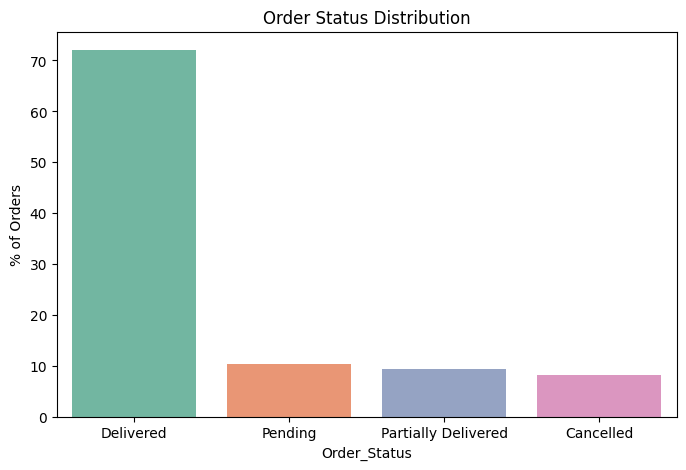

In [47]:
order_status_pct = df['Order_Status'].value_counts(normalize=True) * 100

plt.figure(figsize=(8,5))
sns.barplot(x=order_status_pct.index, y=order_status_pct.values, palette='Set2')
plt.ylabel('% of Orders')
plt.title('Order Status Distribution')
plt.show()


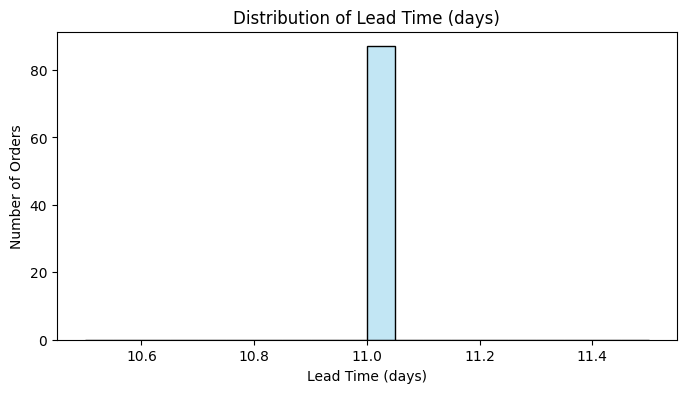

In [48]:
# Calcul du Lead Time si pas déjà fait
df['Lead_Time_Days'] = (df['Delivery_Date_Est_Global'] - df['Order_Date']).dt.days

plt.figure(figsize=(8,4))
sns.histplot(df['Lead_Time_Days'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Lead Time (days)')
plt.xlabel('Lead Time (days)')
plt.ylabel('Number of Orders')
plt.show()


C:\Users\met00546\AppData\Local\Temp\ipykernel_32500\1754725424.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Supplier', y='Defect_Rate_Pct', palette='Reds_r')


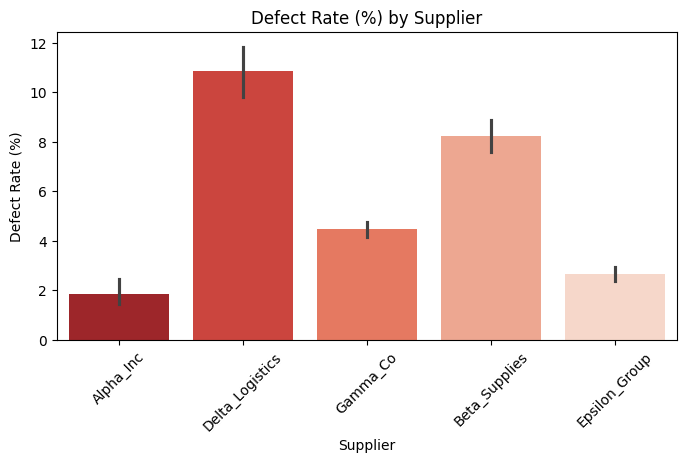

In [49]:
plt.figure(figsize=(8,4))
sns.barplot(data=df, x='Supplier', y='Defect_Rate_Pct', palette='Reds_r')
plt.title('Defect Rate (%) by Supplier')
plt.ylabel('Defect Rate (%)')
plt.xticks(rotation=45)
plt.show()


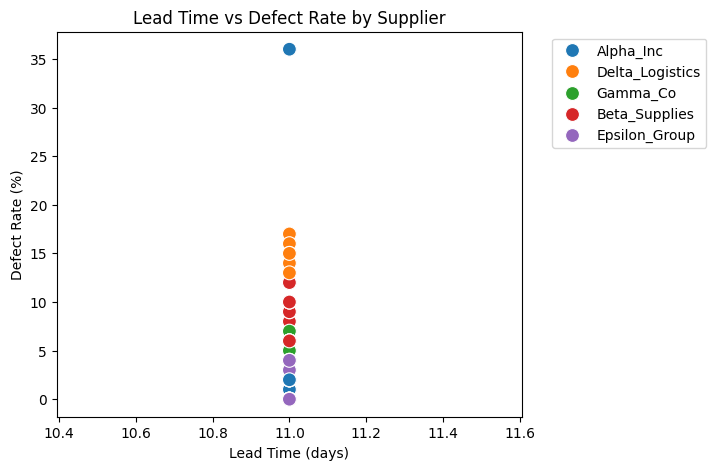

In [50]:
plt.figure(figsize=(6,5))
sns.scatterplot(data=df, x='Lead_Time_Days', y='Defect_Rate_Pct', hue='Supplier', s=100)
plt.title('Lead Time vs Defect Rate by Supplier')
plt.xlabel('Lead Time (days)')
plt.ylabel('Defect Rate (%)')
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.show()


In [ ]:
plt.figure(figsize=(8,4))
sns.barplot(x=avg_saving_by_supplier.index, y=avg_saving_by_supplier.values, palette='Greens_r')
plt.ylabel('Average Saving per Order')
plt.title('Average Cost Saving by Supplier')
plt.xticks(rotation=45)
plt.show()


In [53]:
cancel_rate_by_supplier = (
    df.groupby('Supplier')['Order_Status']
      .apply(lambda x: (x == 'Cancelled').mean() * 100)
      .round(2)
)

cancel_rate_by_supplier


Supplier
Alpha_Inc          9.22
Beta_Supplies      8.97
Delta_Logistics    9.36
Epsilon_Group      8.43
Gamma_Co           4.20
Name: Order_Status, dtype: float64

C:\Users\met00546\AppData\Local\Temp\ipykernel_32500\3552612839.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cancel_rate_by_supplier.index, y=cancel_rate_by_supplier.values, palette='Reds_r')


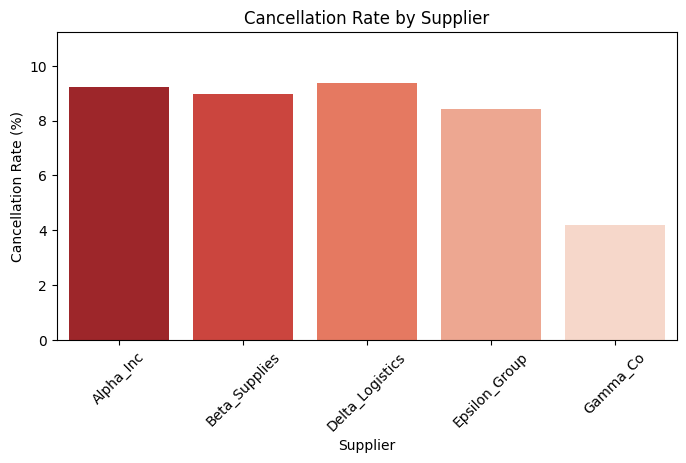

In [54]:
plt.figure(figsize=(8,4))
sns.barplot(x=cancel_rate_by_supplier.index, y=cancel_rate_by_supplier.values, palette='Reds_r')
plt.ylabel('Cancellation Rate (%)')
plt.title('Cancellation Rate by Supplier')
plt.xticks(rotation=45)
plt.ylim(0, max(cancel_rate_by_supplier.values)*1.2)
plt.show()


In [55]:
defect_rate_by_supplier = (
    df.groupby('Supplier')['Defective_Units']
      .apply(lambda x: (x > 0).mean() * 100)
      .round(2)
)

defect_rate_by_supplier


Supplier
Alpha_Inc          77.30
Beta_Supplies      84.62
Delta_Logistics    74.27
Epsilon_Group      84.94
Gamma_Co           89.51
Name: Defective_Units, dtype: float64

In [56]:
avg_defect_pct_by_supplier = (
    df.groupby('Supplier')['Defect_Rate_Pct']
      .mean()
      .round(2)
)

avg_defect_pct_by_supplier


Supplier
Alpha_Inc           1.85
Beta_Supplies       8.26
Delta_Logistics    10.88
Epsilon_Group       2.67
Gamma_Co             4.5
Name: Defect_Rate_Pct, dtype: Float64

C:\Users\met00546\AppData\Local\Temp\ipykernel_32500\60343080.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_defect_pct_by_supplier.index, y=avg_defect_pct_by_supplier.values, palette='Reds_r')


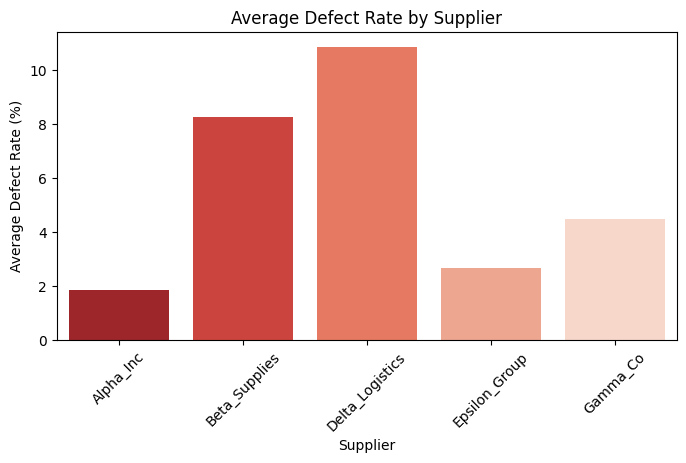

In [57]:
plt.figure(figsize=(8,4))
sns.barplot(x=avg_defect_pct_by_supplier.index, y=avg_defect_pct_by_supplier.values, palette='Reds_r')
plt.ylabel('Average Defect Rate (%)')
plt.title('Average Defect Rate by Supplier')
plt.xticks(rotation=45)
plt.show()
